# KEGG & GO Enrichment of MOA-stratified SHAP Genes

## Overview

This notebook is the continuation of notebook `03_shap_moa_analysis`. Notebook 03 produced, for every mechanism-of-action (MOA) class, a ranked list
of the genes that most strongly drive the drug-response predictions (top genes by mean SHAP). Here we ask a biological question about those lists:

**Do the genes the model relies on form coherent biological programs, and are those programs consistent with what each drug class is known to do?**

To answer it we run **over-representation analysis (ORA)** of each MOA class's top-SHAP genes against curated pathway / ontology databases

## Key design decisions

- **Tool:** `gseapy`. We use `gseapy.enrich()` (local ORA with a custom background) as the primary method, because our feature universe is not the whole genome - it is the variance-selected gene set that entered the models. Using the correct background avoids the classic inflation of significance you get when enrichment tools silently assume a whole-genome background. We keep `gseapy.enrichr()` (online, whole-genome background) as a fallback.
- **Background universe:** the union of all gene features that entered the models
- **Layers are pooled** for enrichment the originating omics layer is kept only as annotation.
- **Multiple testing:** Benjamini–Hochberg FDR 

## 0. Setup

In [1]:
%pip install -q gseapy pandas numpy matplotlib seaborn pyarrow

Note: you may need to restart the kernel to use updated packages.


In [14]:
import os
import re
import json
import textwrap
import warnings
from pathlib import Path

import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import gseapy as gp
print(f"gseapy {gp.__version__}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

PROJECT_DIR = Path.cwd()

gseapy 1.3.0


In [15]:
# Reuse the directory layout from notebook 03
DATA_DIR = PROJECT_DIR / "data"
SHAP_DIR = DATA_DIR / "shap_results_426" # inputs produced by notebook 03
ENRICH_DIR = DATA_DIR / "enrichment_results" # outputs of this notebook
LIB_CACHE = ENRICH_DIR / "gmt_cache" # cached gene-set libraries

for d in (ENRICH_DIR, LIB_CACHE):
    d.mkdir(parents=True, exist_ok=True)

## 1. Load SHAP-derived gene lists

`all_top_genes_by_moa.csv` holds the top-N genes per MOA class with their mean
SHAP importance and the omics layer they came from. This is the direct input
to enrichment: for each MOA class we take its gene list as the "query" set.

In [16]:
top_genes_path = SHAP_DIR / "all_top_genes_by_moa.csv"
all_top_genes = pd.read_csv(top_genes_path)

print(f"Loaded {top_genes_path.name}: {all_top_genes.shape[0]} rows")
print("Columns:", list(all_top_genes.columns))
print("\nGenes per MOA class:")
print(all_top_genes.groupby("moa_class").size().to_string())

# Layer composition of the top genes 
print("\nOmics-layer composition of top genes (count):")
print(pd.crosstab(all_top_genes["moa_class"], all_top_genes["omics_layer"]).to_string())

all_top_genes.head(8)

Loaded all_top_genes_by_moa.csv: 240 rows
Columns: ['gene_name', 'omics_layer', 'mean_abs_shap', 'n_compounds_in_class', 'moa_class']

Genes per MOA class:
moa_class
Cytoskeleton/cell cycle    30
DNA damage/repair          30
Epigenetic                 30
Kinase inhibitor           30
Metabolic                  30
Other/Unknown              30
Proteasome/protein         30
Receptor                   30

Omics-layer composition of top genes (count):
omics_layer              cnv  expr  mut
moa_class                              
Cytoskeleton/cell cycle    4    26    0
DNA damage/repair          3    27    0
Epigenetic                 1    29    0
Kinase inhibitor           2    28    0
Metabolic                  1    29    0
Other/Unknown              1    29    0
Proteasome/protein         2    27    1
Receptor                   2    28    0


,gene_name,omics_layer,mean_abs_shap,n_compounds_in_class,moa_class
0,GPRC5A,expr,0.008499,13,Cytoskeleton/cell cycle
1,SYTL2,expr,0.003805,13,Cytoskeleton/cell cycle
2,THBS1,expr,0.003415,13,Cytoskeleton/cell cycle
3,PLAAT3,expr,0.003192,13,Cytoskeleton/cell cycle
4,MYOF,expr,0.002998,13,Cytoskeleton/cell cycle
5,TM4SF18,expr,0.002730,13,Cytoskeleton/cell cycle
6,GPRC5B,expr,0.002654,13,Cytoskeleton/cell cycle
7,MDFI,expr,0.002517,13,Cytoskeleton/cell cycle


## 2. Build the background universe and clean gene symbols

**Why a custom background matters.** ORA tests whether a query gene list overlaps a pathway more than expected by chance. "By chance" is defined relative to a background universe. Our models were not trained on the whole genome - each omics layer was variance-filtered in notebook 02. If we let the tool assume a ~20,000-gene genomic background, every pathway looks artificially enriched because our universe is already biased toward variable, cancer-relevant genes. The statistically honest background is the set of genes that could have been selected as important

We read those feature names from `shap_per_gene_per_compound.parquet`, strip any `layer::gene` prefix, and normalise to HGNC symbols.

In [17]:
def clean_gene_symbol(name: str) -> str:
    '''Normalise a feature name to a bare HGNC gene symbol. Handles shapes
    DepMap / early-fusion features take, e.g. 'expr::TP53', 'TP53 (7157)',
    'TP53_mut'. Ensembl IDs are left as-is (dropped later).'''
    s = str(name)
    if "::" in s: # early-fusion prefix  layer::gene
        s = s.split("::", 1)[1]
    s = re.sub(r"\s*\(\d+\)\s*$", "", s)  # trailing '(entrez_id)'
    s = re.sub(r"[_\-.](mut|cnv|expr|amp|del)$", "", s, flags=re.I)  # layer suffix
    s = s.strip().upper()
    return s


# Background universe from the full feature set 
gene_parquet = SHAP_DIR / "shap_per_gene_per_compound.parquet"
if gene_parquet.exists():
    df_genes_full = pd.read_parquet(gene_parquet)
    feature_cols = [c for c in df_genes_full.columns if c != "moa_class"]
    background = sorted({clean_gene_symbol(c) for c in feature_cols})
    bg_source = gene_parquet.name
else:
    # Fallback: use the union of the top-gene lists (weaker, whole-genome-ish)
    background = sorted({clean_gene_symbol(g) for g in all_top_genes["gene_name"]})
    bg_source = "top-gene lists (fallback - parquet not found)"

print(f"Background universe: {len(background)} unique symbols (from {bg_source})")
print("Examples:", background[:10])

Background universe: 2804 unique symbols (from shap_per_gene_per_compound.parquet)
Examples: ['A1BG', 'AARD', 'ABCA1', 'ABCA12', 'ABCA13', 'ABCA2', 'ABCA3', 'ABCA4', 'ABCA7', 'ABCA8']


In [19]:
# Clean the per-class query gene lists 
all_top_genes["gene_clean"] = all_top_genes["gene_name"].apply(clean_gene_symbol)

# Drop obvious non-symbols (empty, pure numbers, Ensembl IDs enrichment can't map)
def is_valid_symbol(g: str) -> bool:
    return bool(g) and not g.isdigit() and not g.startswith("ENSG")

all_top_genes["valid_symbol"] = all_top_genes["gene_clean"].apply(is_valid_symbol)
n_bad = (~all_top_genes["valid_symbol"]).sum()
if n_bad:
    print(f"Dropping {n_bad} rows with non-mappable identifiers.")
all_top_genes = all_top_genes[all_top_genes["valid_symbol"]].copy()

# Ensure query genes are contained in the background (ORA requirement)
background = sorted(set(background) | set(all_top_genes["gene_clean"]))

# Build the query dict: MOA class -> list of unique cleaned symbols
query_sets = {
    cls: sorted(set(sub["gene_clean"]))
    for cls, sub in all_top_genes.groupby("moa_class")
}
print("\nQuery gene-set sizes per MOA class:")
for cls, genes in query_sets.items():
    print(f"{cls}: {len(genes)} genes")


Query gene-set sizes per MOA class:
Cytoskeleton/cell cycle: 30 genes
DNA damage/repair: 30 genes
Epigenetic: 30 genes
Kinase inhibitor: 30 genes
Metabolic: 30 genes
Other/Unknown: 30 genes
Proteasome/protein: 30 genes
Receptor: 30 genes


## 3. Enrichment configuration

We test five complementary resources:

| Library | What it captures |
|---|---|
| `KEGG_2021_Human` | canonical signalling / metabolic pathways |
| `GO_Biological_Process_2023` | biological processes (the most interpretable GO branch) |
| `GO_Molecular_Function_2023` | molecular activities (e.g. kinase activity) |
| `GO_Cellular_Component_2023` | subcellular localisation |
| `Reactome_2022` | detailed reaction-level pathways |
| `MSigDB_Hallmark_2020` | 50 broad, well-curated cancer hallmark programs |

Libraries are downloaded once via `gp.get_library()` and cached to disk as JSON.

In [20]:
LIBRARIES = {
    "KEGG": "KEGG_2021_Human",
    "GO_BP": "GO_Biological_Process_2023",
    "GO_MF": "GO_Molecular_Function_2023",
    "GO_CC": "GO_Cellular_Component_2023",
    "Reactome": "Reactome_2022",
    "Hallmark": "MSigDB_Hallmark_2020",
}

# Fallback names in case Enrichr renames a library
LIBRARY_FALLBACKS = {
    "Reactome_2022": ["Reactome_Pathways_2024", "Reactome_2016"],
    "GO_Biological_Process_2023": ["GO_Biological_Process_2021"],
    "GO_Molecular_Function_2023": ["GO_Molecular_Function_2021"],
    "GO_Cellular_Component_2023": ["GO_Cellular_Component_2021"],
    "KEGG_2021_Human": ["KEGG_2019_Human"],
}

FDR_THRESHOLD = 0.05  # Benjamini-Hochberg adjusted p-value
MIN_GENES = 5  # skip MOA classes with fewer mappable genes
TOP_TERMS_PLOT = 12 # terms shown per bar plot

In [22]:
def load_library(enrichr_name: str) -> dict:
    '''Return {term: [genes]} for an Enrichr library, cached to disk. Tries the
    requested name, then any registered fallbacks.'''
    cache_file = LIB_CACHE / f"{enrichr_name}.json"
    if cache_file.exists():
        with open(cache_file) as fh:
            return json.load(fh)

    names_to_try = [enrichr_name] + LIBRARY_FALLBACKS.get(enrichr_name, [])
    for name in names_to_try:
        try:
            lib = gp.get_library(name=name, organism="Human")
            if lib:
                with open(cache_file, "w") as fh:
                    json.dump(lib, fh)
                if name != enrichr_name:
                    print(f"  (used fallback '{name}' for '{enrichr_name}')")
                return lib
        except Exception as exc:
            print(f"  could not fetch '{name}': {exc}")
    print(f"  WARNING: no library available for '{enrichr_name}'")
    return {}


gene_set_libs = {}
for short, enrichr_name in LIBRARIES.items():
    print(f"Loading {short} ({enrichr_name})")
    lib = load_library(enrichr_name)
    if lib:
        gene_set_libs[short] = lib
        print(f"{len(lib)} terms")
print(f"\nLibraries ready: {list(gene_set_libs)}")

Loading KEGG (KEGG_2021_Human)
320 terms
Loading GO_BP (GO_Biological_Process_2023)
5406 terms
Loading GO_MF (GO_Molecular_Function_2023)
1147 terms
Loading GO_CC (GO_Cellular_Component_2023)
472 terms
Loading Reactome (Reactome_2022)
1816 terms
Loading Hallmark (MSigDB_Hallmark_2020)
50 terms

Libraries ready: ['KEGG', 'GO_BP', 'GO_MF', 'GO_CC', 'Reactome', 'Hallmark']


## 4. Run over-representation analysis

For every (MOA class x library) pair we run `gseapy.enrich()` with our custom background. Results are concatenated into one tidy table and cached. Each row is one enriched term with its overlap, p-value, FDR, odds ratio and the overlapping genes 

In [24]:
def run_ora(genes, library_dict, background_list):
    '''Local ORA (hypergeometric) with a custom background. Returns a DataFrame.'''
    try:
        res = gp.enrich(
            gene_list=list(genes),
            gene_sets=library_dict,
            background=list(background_list),
            outdir=None,
            verbose=False,
        )
        return res.results if res is not None else pd.DataFrame()
    except Exception as exc:
        print(f"    gp.enrich failed ({exc}); falling back to online enrichr()")
        try:
            res = gp.enrichr(
                gene_list=list(genes),
                gene_sets=[library_dict] if isinstance(library_dict, dict) else library_dict,
                organism="human",
                outdir=None,
            )
            return res.results if res is not None else pd.DataFrame()
        except Exception as exc2:
            print(f"    enrichr() also failed: {exc2}")
            return pd.DataFrame()


results_cache = ENRICH_DIR / "enrichment_all.csv"

if results_cache.exists():
    enrich_all = pd.read_csv(results_cache)
else:
    records = []
    for cls, genes in query_sets.items():
        if len(genes) < MIN_GENES:
            print(f"[skip] {cls}: only {len(genes)} genes (< {MIN_GENES})")
            continue
        print(f"[{cls}] {len(genes)} genes")
        for short, lib in gene_set_libs.items():
            df = run_ora(genes, lib, background)
            if df.empty:
                continue
            df = df.copy()
            df["moa_class"] = cls
            df["library"]   = short
            records.append(df)

    enrich_all = (pd.concat(records, ignore_index=True)
                  if records else pd.DataFrame())
    enrich_all.to_csv(results_cache, index=False)
    print(f"\nSaved: {results_cache.name} ({len(enrich_all)} rows)")

# Standardise column names across gseapy versions
rename = {"Adjusted P-value": "fdr", "P-value": "pval",
          "Odds Ratio": "odds_ratio", "Combined Score": "combined_score",
          "Term": "term", "Overlap": "overlap", "Genes": "genes"}

enrich_all = enrich_all.rename(columns={k: v for k, v in rename.items() if k in enrich_all.columns})
enrich_all["neg_log10_fdr"] = -np.log10(enrich_all["fdr"].clip(lower=1e-300))
print("\nSignificant terms per class/library:")
sig = enrich_all[enrich_all["fdr"] < FDR_THRESHOLD]
print(pd.crosstab(sig["moa_class"], sig["library"]).to_string()
      if not sig.empty else "(none below threshold)")


Significant terms per class/library:
library                  GO_BP  GO_MF  Hallmark  KEGG  Reactome
moa_class                                                      
Cytoskeleton/cell cycle      0      0         2     0         0
Epigenetic                   5      1         4     0         3
Kinase inhibitor             1      0         2     0         0
Metabolic                    0      4         3     1         0
Other/Unknown                1      0         0     0         3
Proteasome/protein           0      5         0     0         0
Receptor                     1      0         0     0         0


## 5. KEGG pathways per MOA class

KEGG is the most direct link between a drug class and a signalling pathway, so we start here. The bar length is the FDR significance ($-\log_{10}$ adjusted p); the dashed line marks the FDR = 0.05 threshold.

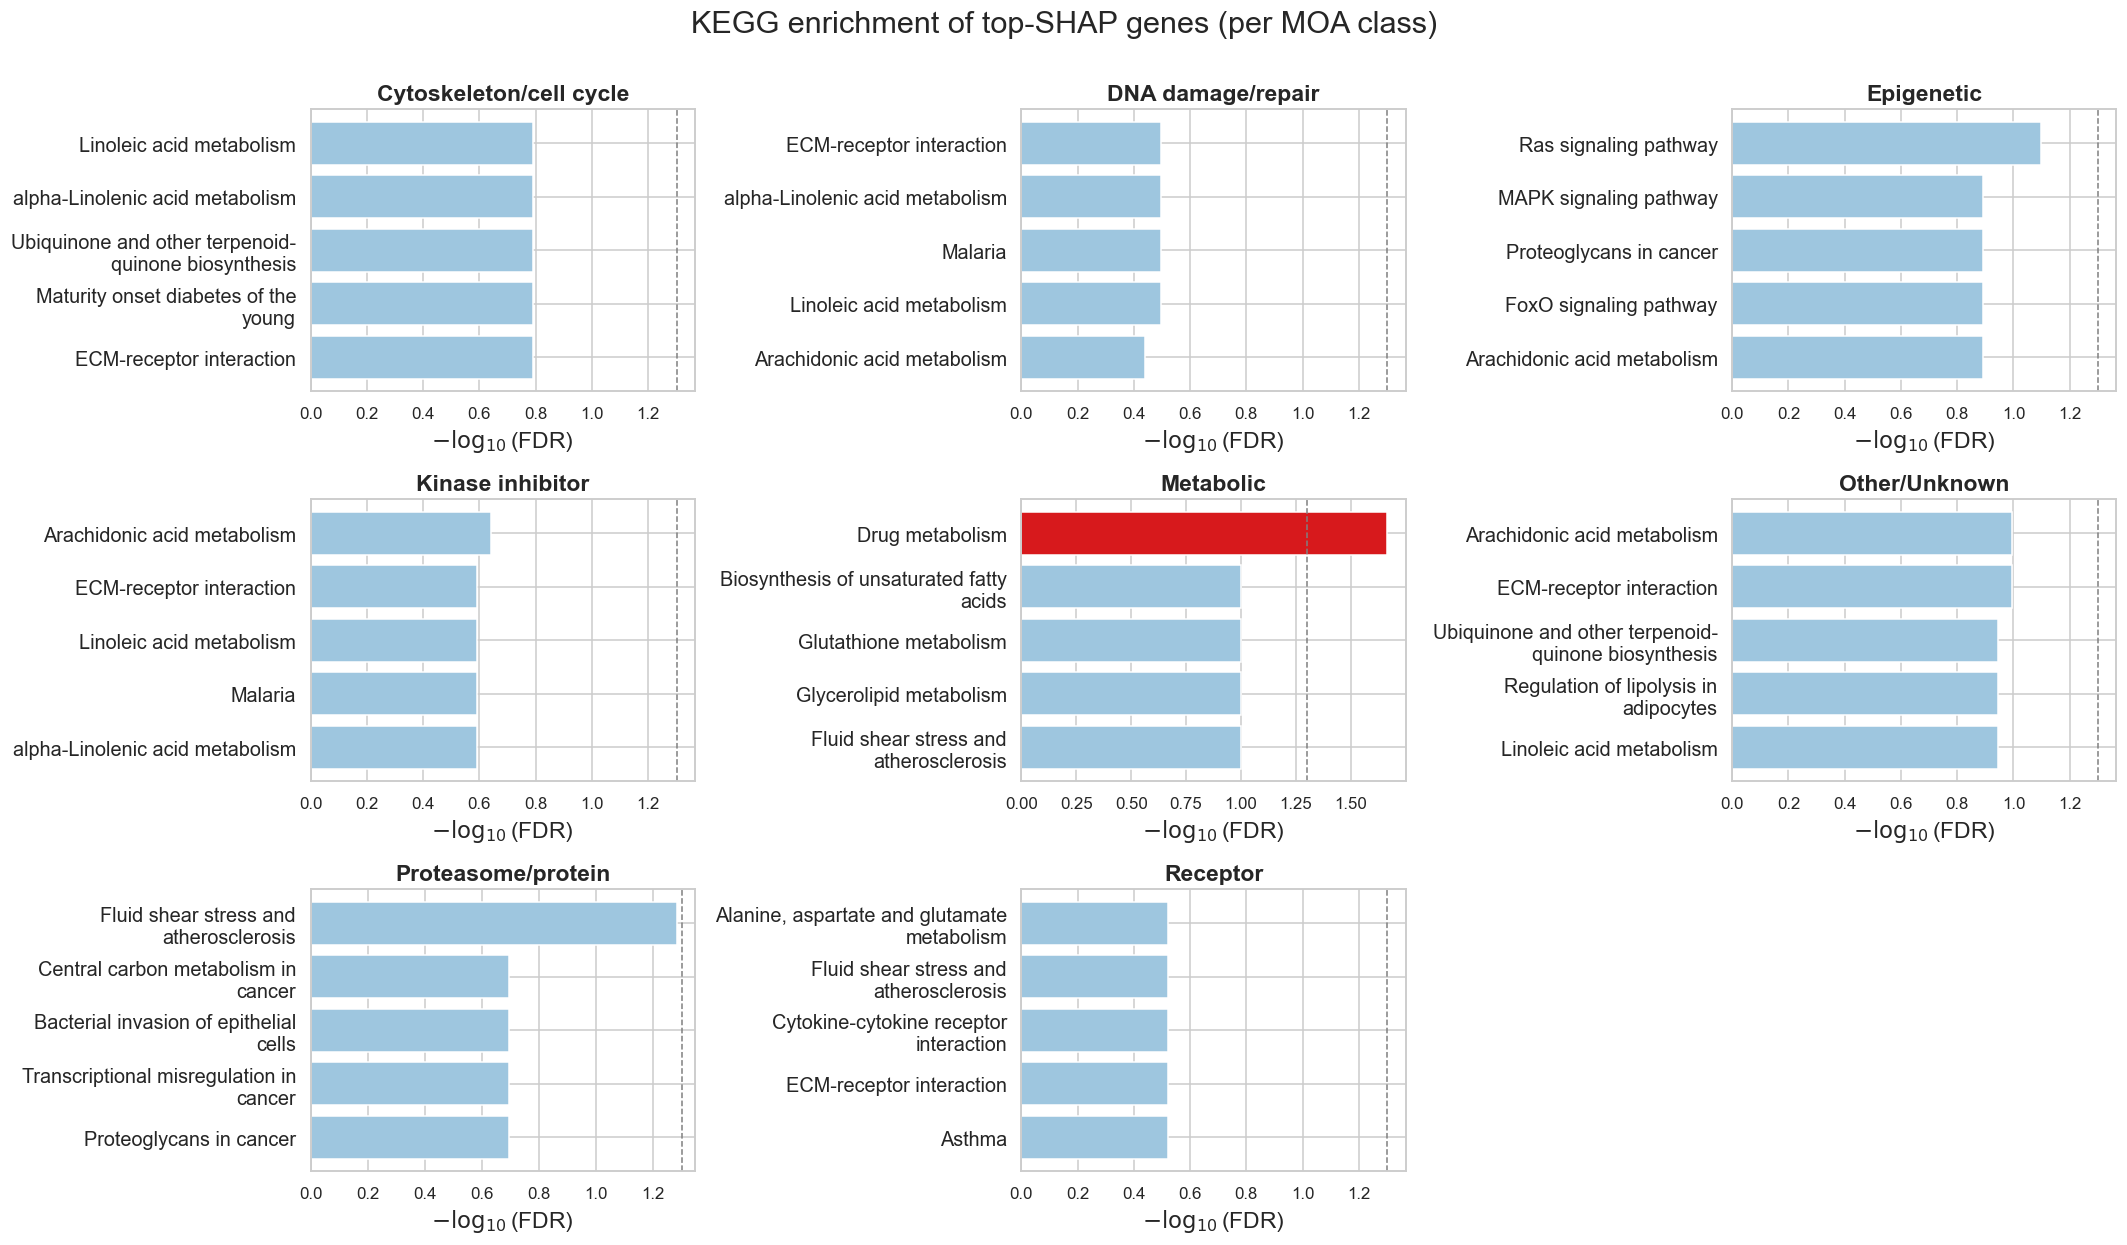

Saved enrichment_KEGG_barplot.png


In [40]:
def plot_enrichment_bars(df, library, top_n=TOP_TERMS_PLOT, n_cols=3):
    '''Grid of horizontal bar panels (n_cols per row), one panel per MOA class, for a given library.'''
    sub = df[df["library"] == library].copy()
    if sub.empty:
        print(f"No results for {library}.")
        return
    classes = sorted(sub["moa_class"].unique())
    n_classes = len(classes)
    n_rows = math.ceil(n_classes / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6.5 * n_cols, (0.45 * top_n + 1.5) * n_rows),
        squeeze=False,
    )
    axes_flat = axes.flatten()
    thr = -np.log10(FDR_THRESHOLD)

    for ax, cls in zip(axes_flat, classes):
        d = (sub[sub["moa_class"] == cls]
             .sort_values("neg_log10_fdr", ascending=False)
             .head(top_n)
             .iloc[::-1])
        if d.empty:
            ax.axis("off"); continue
        colors = ["#d7191c" if f < FDR_THRESHOLD else "#9ec6df" for f in d["fdr"]]
        ax.barh(range(len(d)), d["neg_log10_fdr"], color=colors)
        # wrap long term labels
        labels = [textwrap.fill(re.sub(r"\s*\(GO:\d+\)$", "", t), 34) for t in d["term"]]
        ax.set_yticks(range(len(d)))
        ax.set_yticklabels(labels, fontsize=13)
        ax.axvline(thr, ls="--", lw=1, color="grey")
        ax.set_xlabel(r"$-\log_{10}$(FDR)", fontsize=15)
        ax.set_title(f"{cls}", fontsize=15, fontweight="bold")

    # Turn off any unused axes (when n_classes isn't a multiple of n_cols)
    for ax in axes_flat[n_classes:]:
        ax.axis("off")

    fig.suptitle(f"{library} enrichment of top-SHAP genes (per MOA class)", fontsize=20, y=1.005)
    plt.tight_layout()
    out = ENRICH_DIR / f"enrichment_{library}_barplot.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out.name}")


plot_enrichment_bars(enrich_all, "KEGG", 5)

## Interpretation

**The only significant result across the entire panel** is "Drug metabolism" in the Metabolic class. All other 8 panels (Cytoskeleton/cell cycle, DNA damage/repair, Epigenetic, Kinase inhibitor, Other/Unknown, Proteasome/protein, Receptor) show only blue bars, with no term reaching significance.

**What this means:**
- For the **Metabolic** class, the top-30 SHAP genes are indeed non-randomly concentrated around the drug-metabolism pathway - a direct match with the expected mechanism of this class, and the most robust finding in the whole enrichment analysis.
- For the remaining 7 classes, KEGG fails to detect a significant class-specific pathway. Top terms look similar across classes - this reflects a shared background metabolic/adhesion signature of the cell lines rather than a mechanism-specific finding.

**Why:** the KEGG library contains relatively few (~300) large pathways, each requiring a concentrated gene overlap to reach significance. With only 30 genes per class statistical power is only sufficient to detect the single strongest, most direct signal (Metabolic - Drug metabolism)

In [41]:
# Tabular view of the strongest KEGG hits 
kegg = enrich_all[enrich_all["library"] == "KEGG"].copy()
if not kegg.empty:
    show = (kegg.sort_values(["moa_class", "fdr"])
                .groupby("moa_class")
                .head(8)[["moa_class", "term", "overlap", "fdr",
                          "odds_ratio", "genes"]])
    with pd.option_context("display.max_colwidth", 60):
        display(show.reset_index(drop=True))

,moa_class,term,overlap,fdr,odds_ratio,genes
0,Cytoskeleton/cell cycle,ECM-receptor interaction,3/56,0.161784,6.474257,ITGA3;THBS1;SDC4
1,Cytoskeleton/cell cycle,Linoleic acid metabolism,1/1,0.161784,282.152542,PLAAT3
2,Cytoskeleton/cell cycle,Maturity onset diabetes of the young,1/2,0.161784,94.016949,FOXA2
3,Cytoskeleton/cell cycle,Ubiquinone and other terpenoid-quinone biosynthesis,1/1,0.161784,282.152542,NQO1
4,Cytoskeleton/cell cycle,alpha-Linolenic acid metabolism,1/2,0.161784,94.016949,PLAAT3
...,...,...,...,...,...,...
59,Receptor,Cytokine-cytokine receptor interaction,3/46,0.301308,7.991850,CCL3L3;LIF;CD40
60,Receptor,ECM-receptor interaction,3/56,0.301308,6.474257,ITGA3;SDC4;LAMB2
61,Receptor,Fat digestion and absorption,1/7,0.301308,21.657106,CLPS
62,Receptor,Fluid shear stress and atherosclerosis,2/37,0.301308,6.769212,ASS1;SDC4


## 6. GO enrichment (BP / MF / CC)

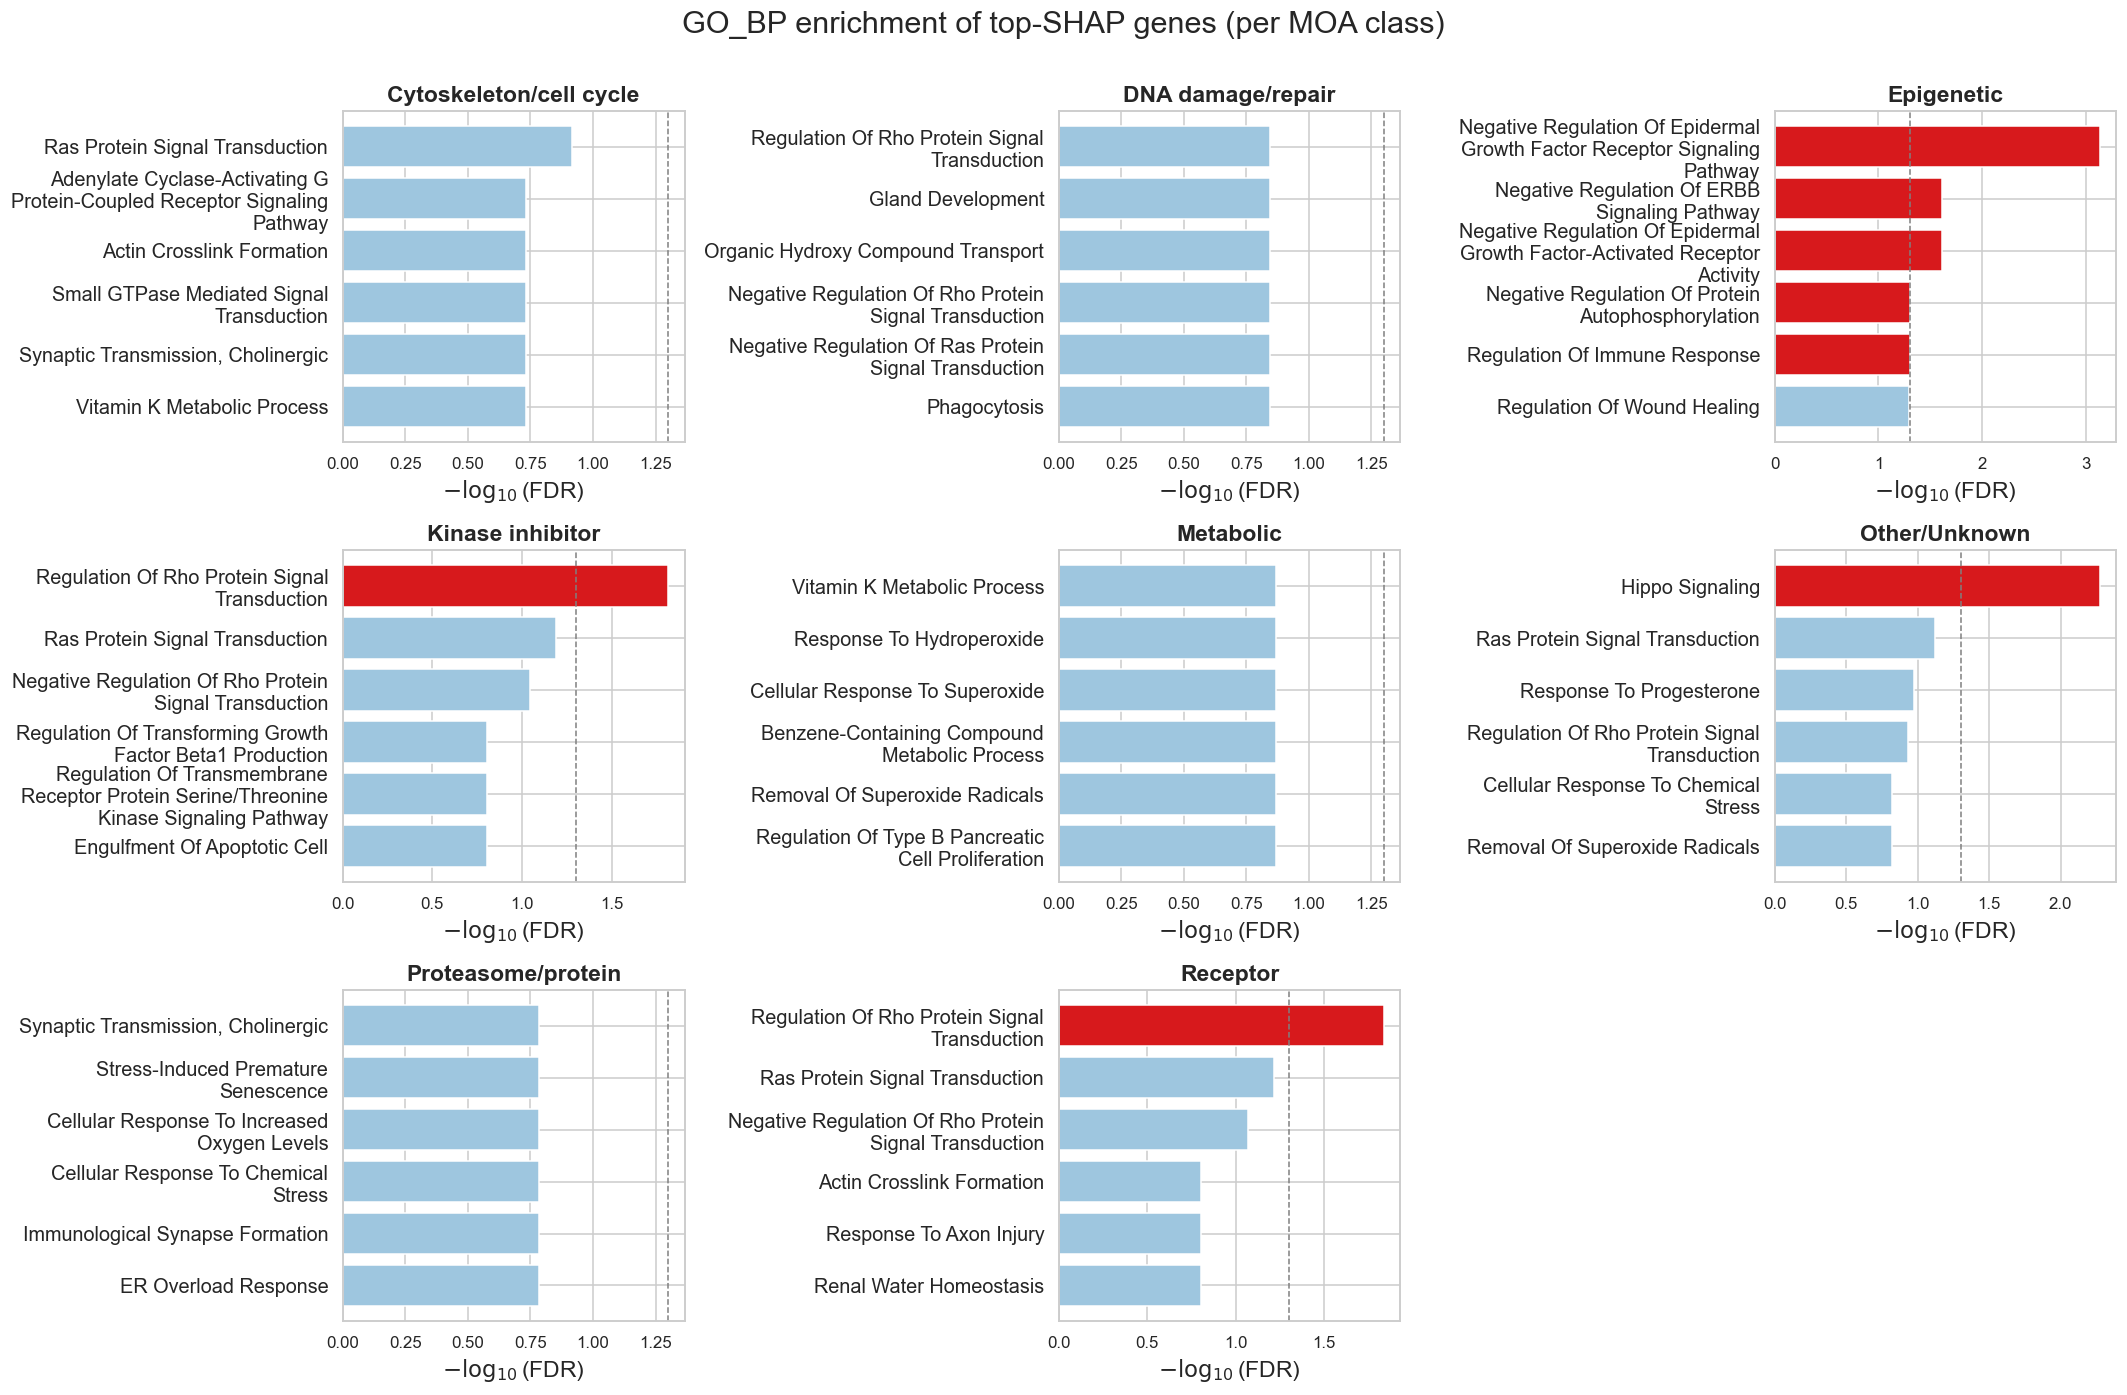

Saved enrichment_GO_BP_barplot.png


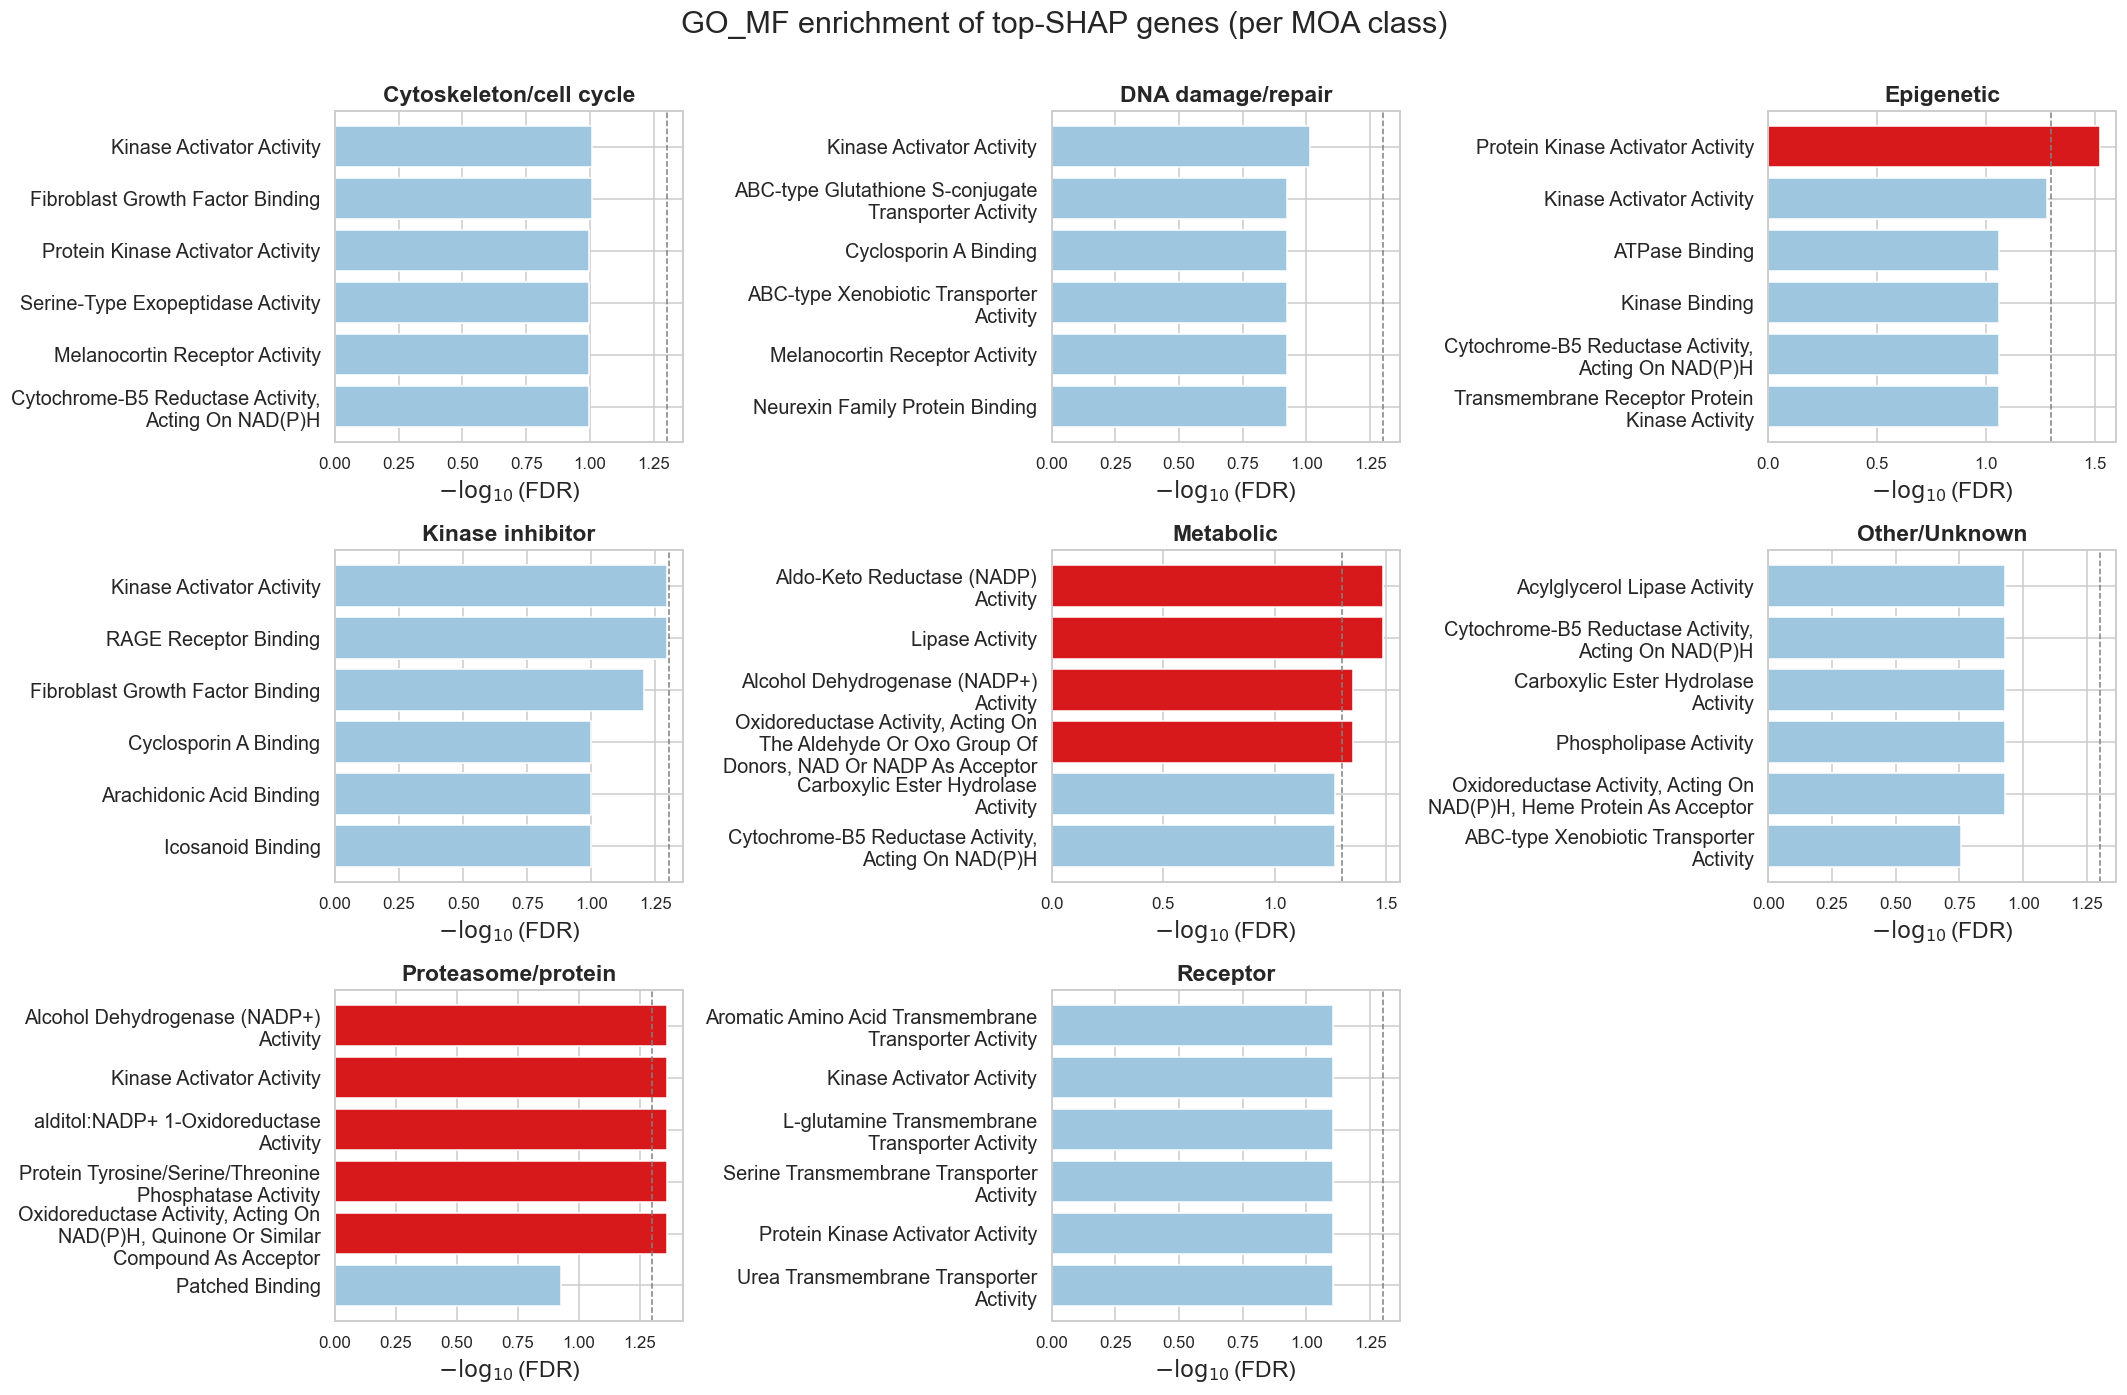

Saved enrichment_GO_MF_barplot.png


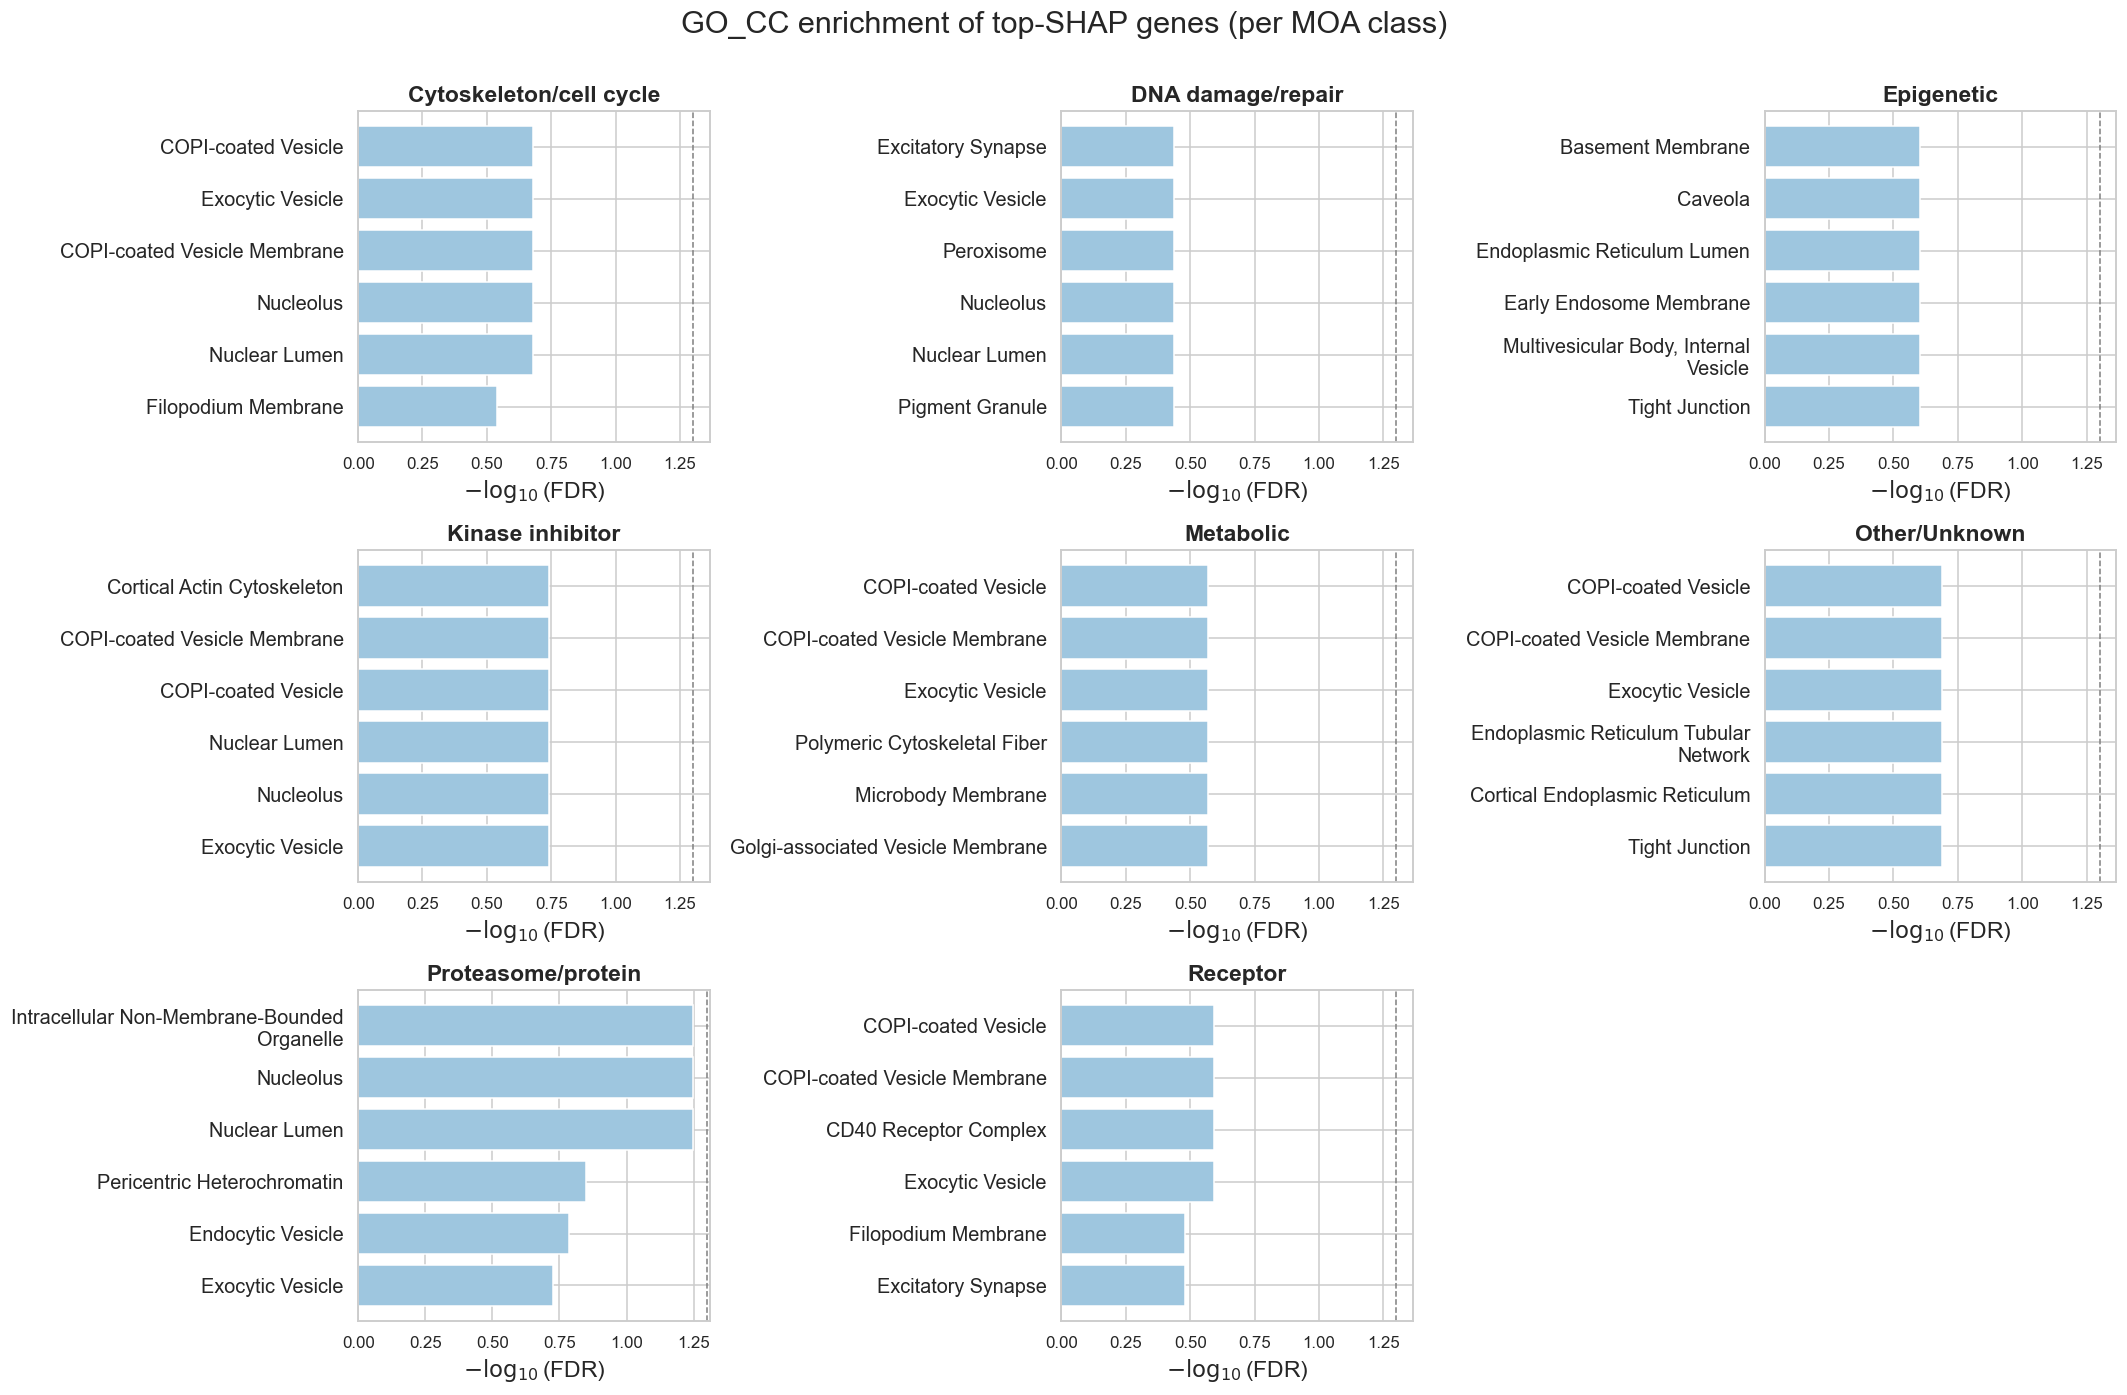

Saved enrichment_GO_CC_barplot.png


In [43]:
for lib in ["GO_BP", "GO_MF", "GO_CC"]:
    if (enrich_all["library"] == lib).any():
        plot_enrichment_bars(enrich_all, lib, top_n=6)

### Biological Interpretation

#### What we expected to see

For each mechanism-of-action (MOA) class, we expected the model's top-SHAP genes to trace back to the biological pathway that drug class is known to act on — confirming the model learned real biology rather than noise.

#### What we found, and why it makes sense

**Metabolic - drug metabolism / oxidative stress.** Cells have a built-in enzyme system that breaks down foreign substances, including drugs, so they can be cleared — a side effect of which is the production of damaging molecules that trigger an antioxidant response. This is the cleanest match in the analysis: the biological process found matches the drug class's actual mechanism almost exactly. A cell line that clears the drug efficiently is more resistant; one that can't is more sensitive.

**Epigenetic - EGFR-pathway** EGFR is a growth receptor, cells have natural brake genes that keep it in check. Epigenetic drugs don't hit one protein directly - they loosen or tighten how DNA is packaged, switching genes on or off genome-wide. In many cells, the EGFR-brake genes get silenced by tight DNA packaging, an epigenetic drug reopens that packaging and reactivates them. So EGFR isn't the drug's target - it's a readout of the drug's real target (chromatin state), which is why it predicts sensitivity. A fifth bar, *Regulation Of Immune Response*, points to a separate, weaker thread (epigenetic drugs are known to reactivate immune genes cancer cells silence to evade detection) - plausible, but not clearly tied to the same genes as the EGFR story, so best treated cautiously.

**Kinase inhibitor & Receptor - shared internal signaling relay** Rho is a molecular "switch" inside the cell that, when activated, drives cell movement and division. It sits downstream of both surface receptors and the kinases they trigger - receptor activation switches kinases on, and kinases switch Rho on. Kinase inhibitors block that activation from inside the cell; receptor-targeted drugs block it one step earlier, at the surface. Both drug types interrupt the same relay at different points, so the same Rho-pathway signal showing up for both classes is expected, not coincidental.

**Other/Unknown - Hippo Signaling (general growth control).** This is a broad, generic growth-limiting pathway.That is expected because there's no specific mechanism to uncover.

**Proteasome/protein - same oxidative-stress machinery as Metabolic**  Blocking the proteasome (this class's actual target) causes damaged-protein buildup, which independently triggers the same kind of oxidative stress that drug metabolism causes. 

**GO_CC (cellular component) - no significant result for any class, and that's expected.** This category asks where in the cell a protein physically sits, not what it does - a weaker, less mechanism-relevant angle, since proteins with completely different functions often share the same location. A null result here doesn't contradict the positive findings above. it's closer to a negative control confirming an uninformative angle stayed uninformative.

### Limitations

1. **Small gene lists (30 per class)** give the statistical test low power - a single gene can single-handedly produce or block a result.
2. **Enrichment shows correlation, not causation** - even confirmed pathways reflect what the model uses to predict response, not necessarily the drug's direct target (clearest in the Epigenetic and Proteasome/protein results above).

## 7. Cross-MOA comparison

A term x class heatmap ($-\log_{10}$ FDR) shows at a glance which pathways are shared across drug classes (general response biology) versus class-specific (mechanism fingerprints)

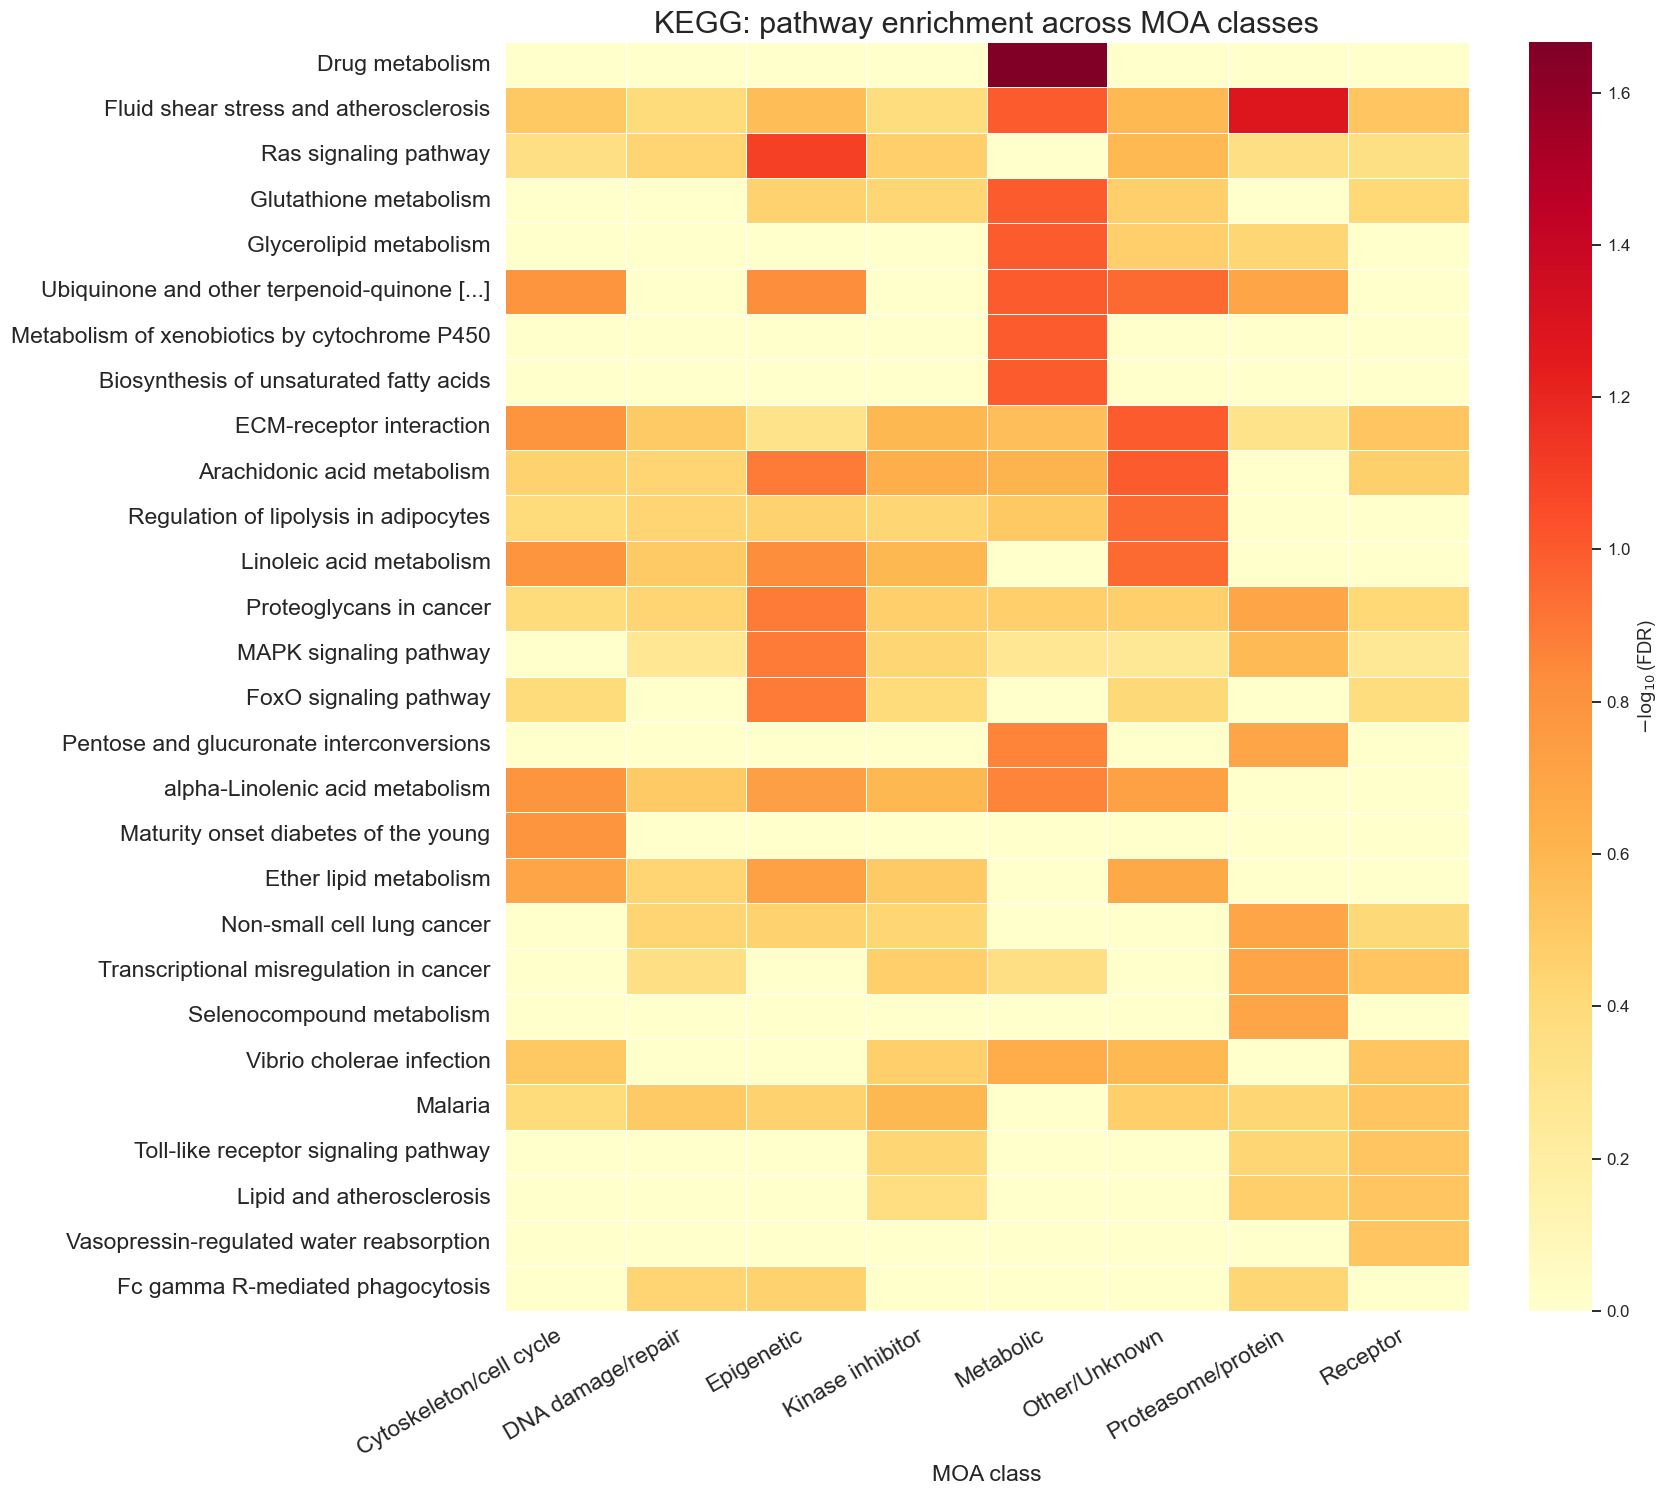

Saved enrichment_KEGG_heatmap.png


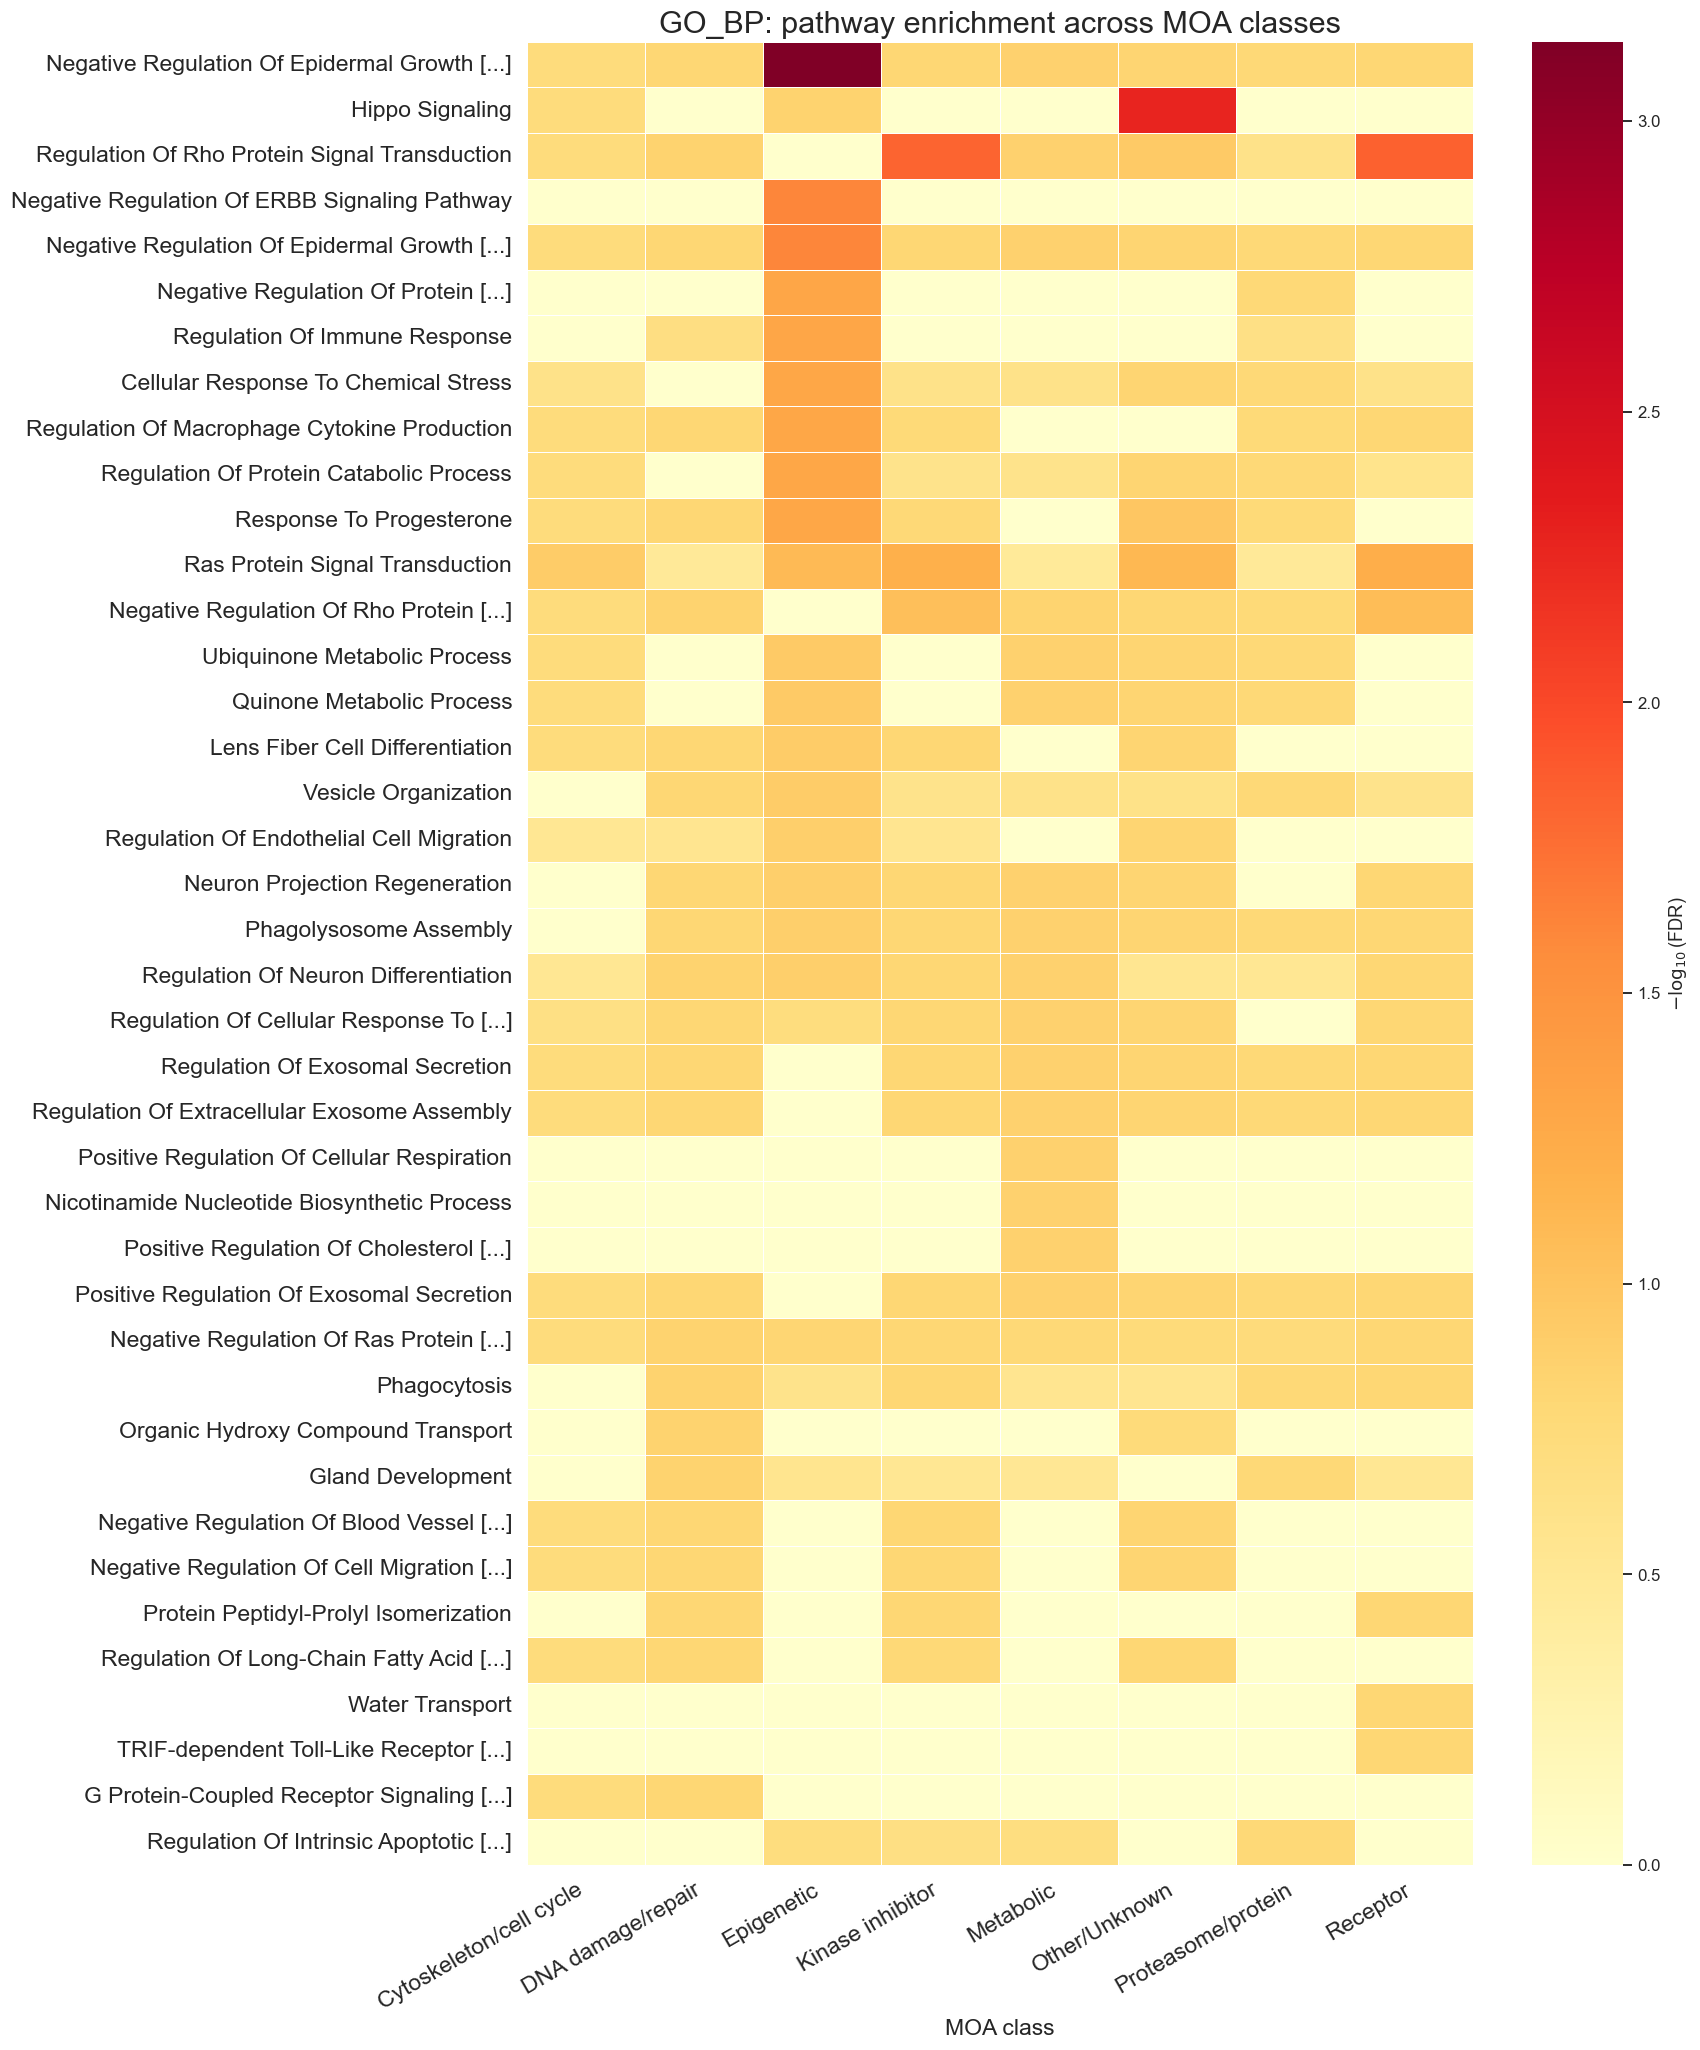

Saved enrichment_GO_BP_heatmap.png


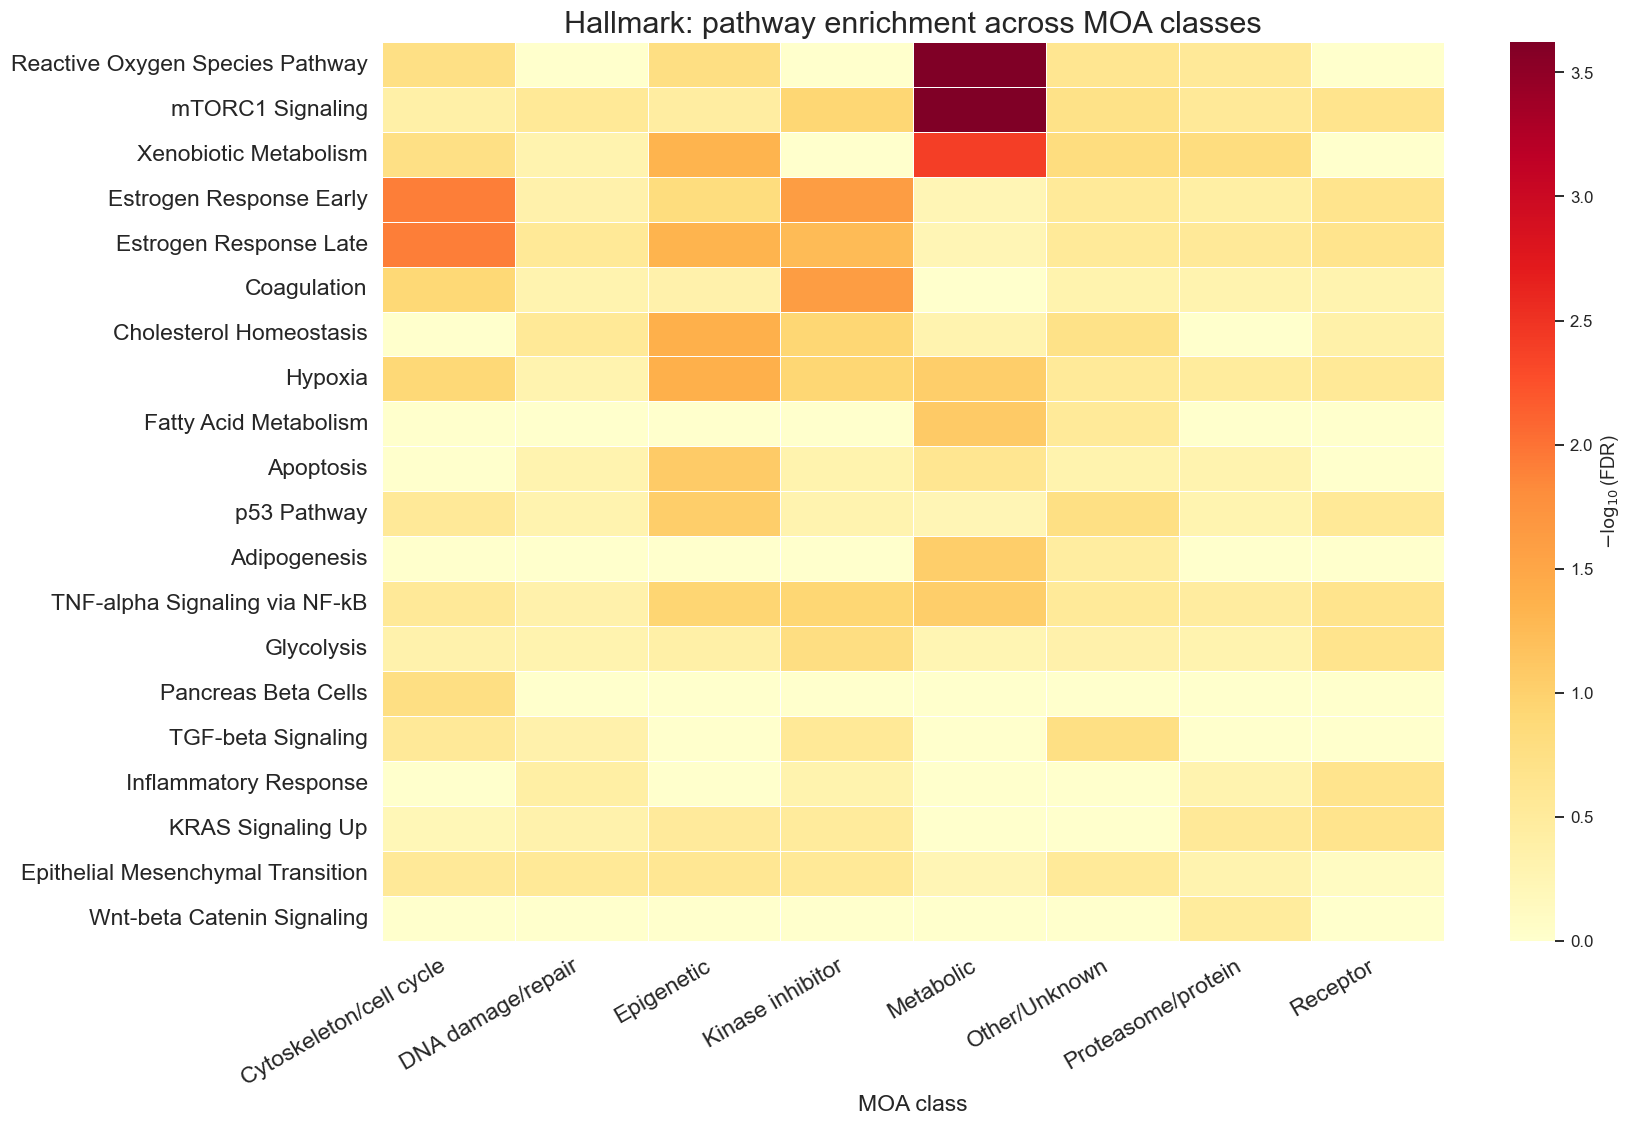

Saved enrichment_Hallmark_heatmap.png


In [50]:
def enrichment_heatmap(df, library, top_per_class=6):
    sub = df[df["library"] == library].copy()
    if sub.empty:
        print(f"No {library} results."); return
    # union of the top terms of each class
    keep_terms = (sub.sort_values("neg_log10_fdr", ascending=False)
                     .groupby("moa_class")
                     .head(top_per_class)["term"].unique())
    mat = (sub[sub["term"].isin(keep_terms)]
           .pivot_table(index="term", columns="moa_class",
                        values="neg_log10_fdr", aggfunc="max")
           .fillna(0))
    if mat.empty:
        print("Nothing to plot."); return
    mat = mat.loc[mat.max(axis=1).sort_values(ascending=False).index]
    mat.index = [textwrap.shorten(re.sub(r"\s*\(GO:\d+\)$", "", t), 46)
                 for t in mat.index]
    fig, ax = plt.subplots(figsize=(1.6 * mat.shape[1] + 3,
                                    0.42 * mat.shape[0] + 2))
    sns.heatmap(mat, cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": r"$-\log_{10}$(FDR)"}, ax=ax)
    ax.set_title(f"{library}: pathway enrichment across MOA classes",
                 fontsize=20)
    ax.set_xlabel("MOA class", fontsize=15); ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=15)
    plt.xticks(rotation=30, ha="right", fontsize=15)
    plt.tight_layout()
    out = ENRICH_DIR / f"enrichment_{library}_heatmap.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out.name}")


for lib in ["KEGG", "GO_BP", "Hallmark"]:
    if (enrich_all["library"] == lib).any():
        enrichment_heatmap(enrich_all, lib)

### Cross-class comparison 

#### What this view is for

The earlier bar charts showed, one class at a time, "which pathways are significant for this drug class." These heatmaps put all eight classes side by side for the same pathway, so we can see: whether a pathway is unique to one drug class (a real fingerprint) or lights up across many classes at once (a generic background signal shared by most drugs). 

#### What we see, and why

**Genuinely class-specific signals (dark cell in one column, pale everywhere else):**

- **EGFR-pathway terms, dark only under Epigenetic** (GO_BP heatmap) - consistent with the previous result
- **"Drug metabolism," dark only under Metabolic** (KEGG heatmap) - the cleanest, most specific result across all three heatmaps. This term refers to the group of genes that chemically process and clear foreign compounds from the cell, which is exactly the expected mechanism for this drug class.
- **"Reactive Oxygen Species Pathway" and "mTORC1 Signaling," dark only under Metabolic** (Hallmark heatmap). ROS is the antioxidant-defense system covered earlier. mTORC1 Signaling: it's a central "sensor" inside the cell that monitors stress and nutrient status and adjusts the cell's metabolism in response - it's expected to activate together with the drug-processing/oxidative-stress genes
- **"Hippo Signaling," dark only under Other/Unknown** (GO_BP heatmap) - as covered earlier: a generic growth-control pathway, fitting for a class with no defined mechanism.
- **"Ras signaling pathway," dark only under Epigenetic** (KEGG heatmap). Ras is a signaling switch similar in role to Rho (covered earlier) - it sits downstream of growth receptors like EGFR and relays their signal onward. Its appearance here lines up with, and reinforces, the same EGFR-related finding seen in GO_BP.

**Shared background signals:**

- **"Regulation Of Rho Protein Signal Transduction"** (GO_BP) - elevated in Kinase inhibitor and receptor MOA, it is expected because kinase inhibitors block that activation from inside the cell; receptor-targeted drugs block it one step earlier, at the surface (as discussed above)
- **"Fluid shear stress and atherosclerosis"** (KEGG) — elevated broadly, strongest for Proteasome/protein and Metabolic. This term refers to genes involved in how cells respond to physical/mechanical stress and vascular injury - a broad cellular-stress signature, not tied to any one drug mechanism
- **"ECM-receptor interaction"** (KEGG) - elevated across nearly every column. This describes genes involved in how a cell attaches to and senses its surrounding structural scaffold - again a general cell-state signature common to many response contexts
- **"Estrogen Response Early/Late"** (Hallmark) - elevated for Cytoskeleton/cell cycle, Epigenetic, and Kinase inhibitor simultaneously. This tracks genes that respond to estrogen-driven cell growth signaling, its presence across three unrelated classes suggests it reflects a hormone-driven proliferation trait of certain cell lines rather than a class-specific drug mechanism.
- **"Xenobiotic Metabolism"** (Hallmark) - technically strongest under Metabolic (consistent with the class)

## 8. Limitations

1. **Small query lists (top-30 genes per class).** Statistical power stays limited for some pathway databases - a single gene can still make or break a significant result.

2. **Small-pathway artifacts remain.** Several hits rest on pathways with only 1-3 genes total (overlap "1/1", "2/2"), where one matching gene inflates the odds ratio regardless of MOA coverage 

3. **Correlation, not causation.** Enriched pathways reflect what the model uses to predict response, not necessarily the drug's direct target 

4. **Ontology redundancy.** GO terms overlap and nest hierarchically, so several "significant" rows per class often derive from the same one or two underlying genes annotated across multiple related terms, rather than independent evidence. Results should be read as a handful of distinct biological signals, not a proportional count of findings.

In [52]:
# Summary
print(f"\nMOA classes tested: {enrich_all['moa_class'].nunique() if not enrich_all.empty else 0}")
print(f"Libraries queried: {list(gene_set_libs)}")
print(f"Background universe: {len(background)} genes")
print(f"Total enriched rows: {len(enrich_all)}")
if not enrich_all.empty:
    n_sig = (enrich_all['fdr'] < FDR_THRESHOLD).sum()
    print(f"Significant (FDR<{FDR_THRESHOLD}): {n_sig}")

print(f"\nOutputs saved to {ENRICH_DIR}:")
for p in sorted(ENRICH_DIR.rglob("*")):
    if p.is_file() and p.parent.name != "gmt_cache":
        print(f"  {p.relative_to(ENRICH_DIR)}")


MOA classes tested: 8
Libraries queried: ['KEGG', 'GO_BP', 'GO_MF', 'GO_CC', 'Reactome', 'Hallmark']
Background universe: 2804 genes
Total enriched rows: 6559
Significant (FDR<0.05): 36

Outputs saved to C:\Users\pikil\Multi-Omics-Mechanism-Modelling-AAC\data\enrichment_results:
  enrichment_all.csv
  enrichment_GO_BP_barplot.png
  enrichment_GO_BP_heatmap.png
  enrichment_GO_CC_barplot.png
  enrichment_GO_MF_barplot.png
  enrichment_Hallmark_heatmap.png
  enrichment_KEGG_barplot.png
  enrichment_KEGG_heatmap.png
  leading_edge_genes.csv
  shap_dropoff_check.png
